# Phase 8 - Entire Data Preprocessing

**Project:** “Machine Learning approaches for accelerating antibiotic susceptibility testing (AST) in microfluidic systems” 

**Date:** May 2026 

## 1. Introduction

This notebook applies the preprocessing pipeline to all experimental datasets from E. coli and S. aureus. The objective is to validate data integrity, standardise concentration labels, identify missing values, evaluate experiment duration, assess variability across replicates, and prepare the complete dataset for downstream analysis.

During preprocessing, one unnamed S. aureus ampicillin worksheet was assigned the identifier 20249999_5ee. Additionally, one worksheet (20251028_5e4) was excluded because it did not contain a complete raw/processed data structure.

### Objectives
- Apply the preprocessing pipeline to all experimental datasets
- Validate data quality and structural consistency
- Standardise concentration labels and verify missing values
- Assess experiment duration
- Generate plots
- Export the processed datasets for subsequent analyses

## Table of Contents
1. [Introduction](#1-introduction)
2. [Imports and setup](#2-imports-and-setup)
3. [Import Libraries and Function](#3-import-libraries-and-functions)
4. [Load raw experimental files](#4-load-raw-experimental-files)
5. [E. coli](#5-e-coli)
6. [S. aureus](#6-s-aureus)
7. [Save Dataset](#7-save-dataset)

## Table of Contents

## 2. Imports and Setup

In [ ]:
from pathlib import Path
import pandas as pd
import re

# -- Serialisation -----
import pickle

# -- Project functions -------
from Prepocessing_functions_8 import *

## 3. Import Libraries and Functions

In [ ]:
# Path to the raw data file
path = Path(r"C:/Users/eduar/Desktop/Projeto em Bioinformática/Codigo/dados_brutos") # Important: Change Path
files = list(path.glob("*.xlsx"))

print(f"Encontrei {len(files)} ficheiros")

Encontrei 11 ficheiros


## 4. Load Raw Experimental Files

In [3]:
path_ecoli = []
path_saureus = []
for file in files:
    if "E.coli_25922" in str(file):
        parts = file.stem.split("_")  
        antibiotic = parts[-1]
        path_ecoli.append([antibiotic, file])
    elif "S.aureus_29213" in str(file):
        parts = file.stem.split("_")  
        antibiotic = parts[-1]
        path_saureus.append([antibiotic, file])

In [4]:
print(f"Existem {len(path_ecoli)} ficheiros de E. coli")
print(f"Existem {len(path_saureus)} ficheiros de S. aureus")

Existem 5 ficheiros de E. coli
Existem 6 ficheiros de S. aureus


## 5. E COLI

### 5.1 Dataset Preparation

In [5]:
ecoli_data = {}
for ficheiro in path_ecoli:
    antibiotico = ficheiro[0]
    path = ficheiro[1]
    dados = get_dataset(path)
    dados = clean_Nas(dados)
    ecoli_data.update({antibiotico : dados})

In [6]:
for antibiotico in ecoli_data:
    for date in ecoli_data[antibiotico]:
        for concentration in ecoli_data[antibiotico][date]:
            for sample_type in ecoli_data[antibiotico][date][concentration]:
                None

In [7]:
def clean_conc(col):
    col = str(col).strip()
    col = re.sub(r"\.\d+$", "", col)
    if col in ["PC", "Positive control", "P"]:
        return "0"
    if col.startswith("Unnamed"):
        return None
    return col


In [8]:
concs = set()
for antibiotico in ecoli_data:
    for date in ecoli_data[antibiotico]:
        for concentration in ecoli_data[antibiotico][date]:
            for sample_type in ecoli_data[antibiotico][date][concentration]:
                df = (ecoli_data[antibiotico][date][concentration][sample_type])
                df.columns = [clean_conc(col) for col in df.columns] 
                concs.update([c for c in df.columns if c != "Time(hrs)"])
        


### 5.2 Missing Value Assessment

In [9]:
na_found = False

for antibiotico in ecoli_data:
    for date in ecoli_data[antibiotico]:
        for concentration in ecoli_data[antibiotico][date]:
            for sample_type in ecoli_data[antibiotico][date][concentration]:
                df = (ecoli_data[antibiotico][date][concentration][sample_type])
                if df.isna().any().any():
                    print(f"  NAs found in:{antibiotico} {date} - {concentration} - {sample_type}")
                    na_found = True

if not na_found:
    print("No missing values found in the dataset.")

No missing values found in the dataset.


### 5.3 Ecoli Data exploration

In [10]:
experiments  = list(ecoli_data.keys())
data_types    = list(ecoli_data[experiments[0]].keys())
bac_conc   = list(ecoli_data[experiments[0]][data_types[0]].keys())

print("Experiments :", experiments)
print("Concentrations :", bac_conc)
print("Data types :", data_types)

Experiments : ['ampicillin', 'ciprofloxacin', 'gentamicin', 'tetracycline', 'trimethoprim']
Concentrations : ['5e6', '5e5', '5e4']
Data types : ['20230508', '20230516', '20230518']


In [11]:
duration = {}
for antibiotico in ecoli_data:
    duration[antibiotico] = {}
    for date in ecoli_data[antibiotico]:
        duration[antibiotico][date] = {}
        for concentration in ecoli_data[antibiotico][date]:
            df = ecoli_data[antibiotico][date][concentration]["gvr"]
            last_timepoint = round(df.iloc[-1, 0], 2)
            duration[antibiotico][date][concentration] = last_timepoint

print("Duration per condition (hours):")
print(duration)

Duration per condition (hours):
{'ampicillin': {'20230508': {'5e6': 11.0, '5e5': 13.33, '5e4': 11.0}, '20230516': {'5e6': 18.17, '5e5': 18.17, '5e4': 18.17}, '20230518': {'5e6': 16.33, '5e5': 16.33, '5e4': 16.33}}, 'ciprofloxacin': {'20250717': {'5e5': 39.67}, '20250719': {'5e5': 39.0}, '20250728': {'5e5': 21.0}}, 'gentamicin': {'20250717': {'5e5': 39.67}, '20250719': {'5e5': 39.17}, '20250728': {'5e5': 21.0}}, 'tetracycline': {'20240118': {'5e6': 33.0, '5e4': 33.17, '5e5': 33.33}, '20240126': {'5e6': 42.5, '5e5': 42.5, '5e4': 42.5}, '20240203': {'5e6': 33.33, '5e5': 29.17, '5e4': 29.17}}, 'trimethoprim': {'20250717': {'5e5': 39.5}, '20250719': {'5e5': 39.0}, '20250728': {'5e5': 21.0}}}


### 5.4 Display Dataset

In [25]:
for antibiotico in ecoli_data:
    for date in ecoli_data[antibiotico]:
        for concentration in ecoli_data[antibiotico][date]:
            df = ecoli_data[antibiotico][date][concentration]["gvr"]
            #display(df) 

### 5.5 Standard deviation analysis (GVR)

Antibiotico ampicillin |Experiment: 20230508  |  Concentration: 5e6
std inicial: 0.0088
std final: 1.4059


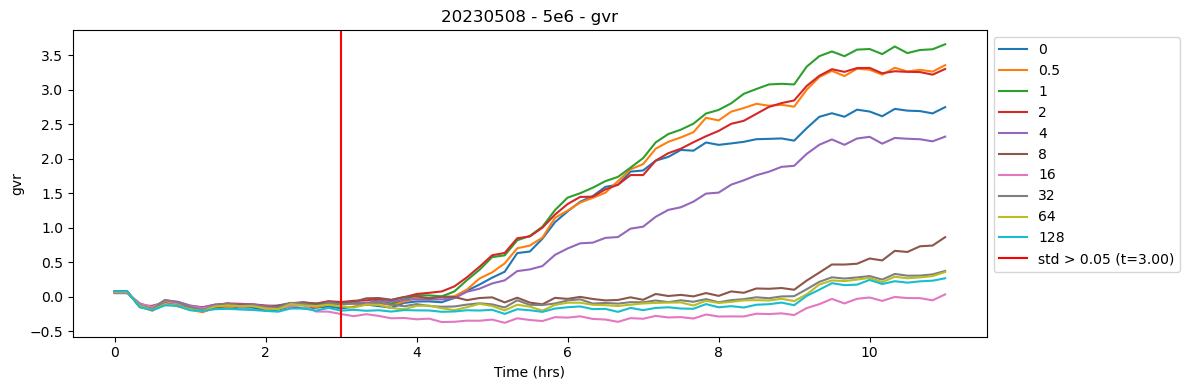


Antibiotico ampicillin |Experiment: 20230508  |  Concentration: 5e5
std inicial: 0.0043
std final: 1.0448


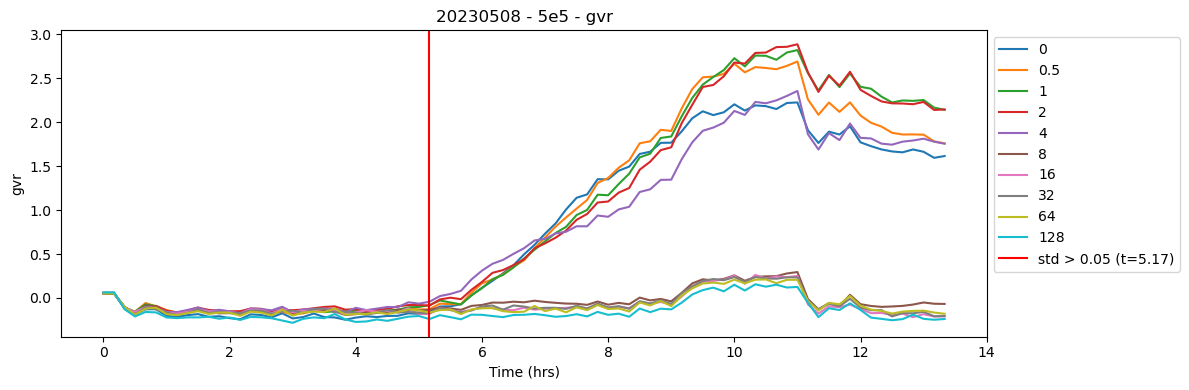


Antibiotico ampicillin |Experiment: 20230508  |  Concentration: 5e4
std inicial: 0.0067
std final: 1.2521


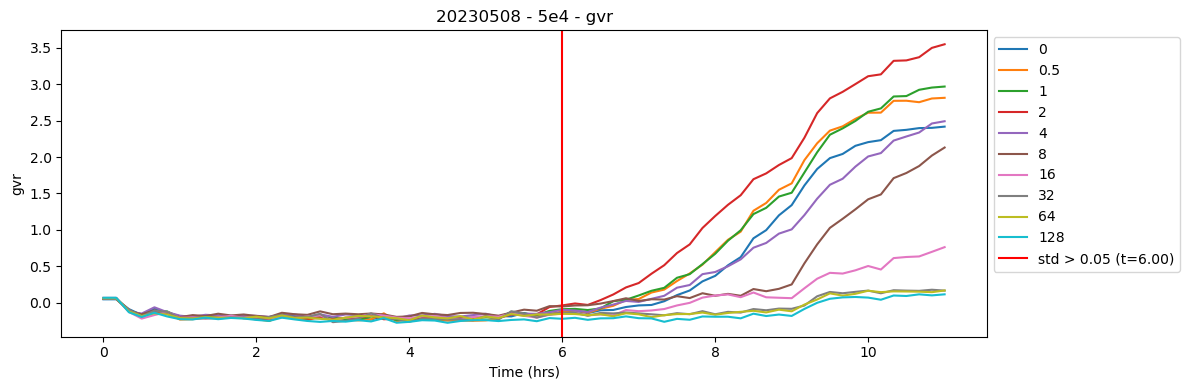


Antibiotico ampicillin |Experiment: 20230516  |  Concentration: 5e6
std inicial: 0.0080
std final: 0.2036


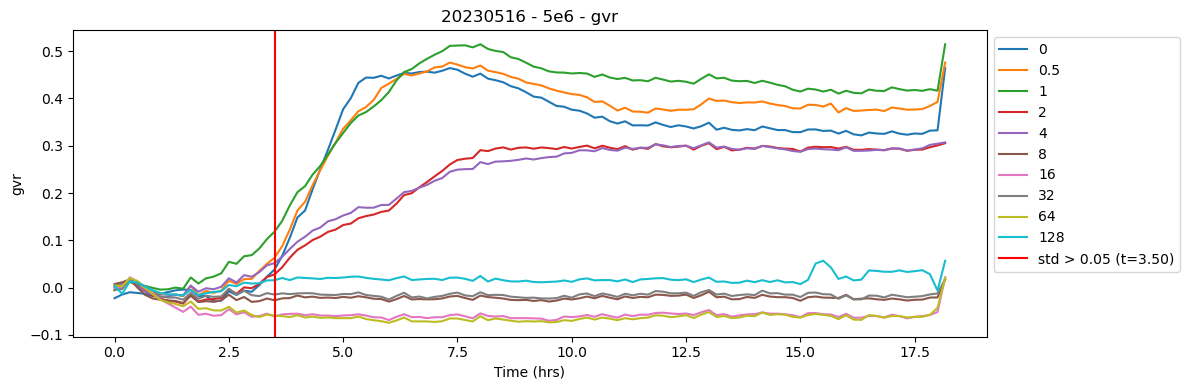


Antibiotico ampicillin |Experiment: 20230516  |  Concentration: 5e5
std inicial: 0.0170
std final: 0.4331


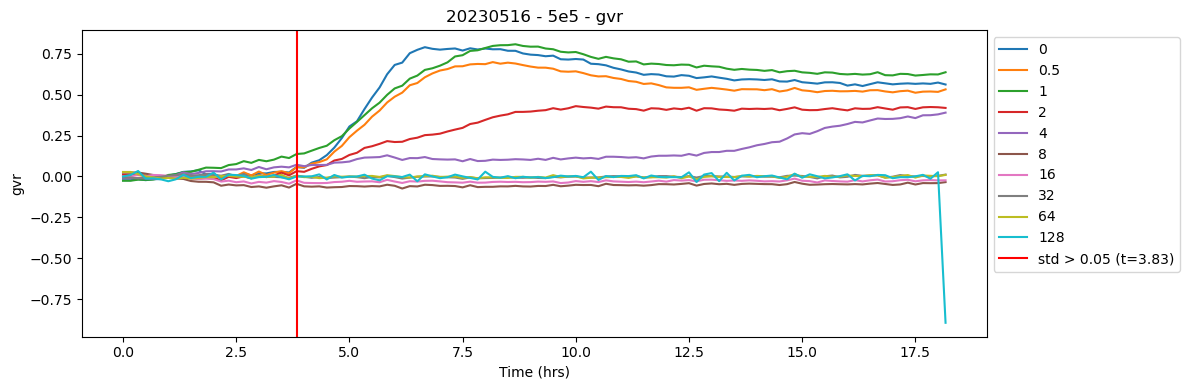


Antibiotico ampicillin |Experiment: 20230516  |  Concentration: 5e4
std inicial: 0.0180
std final: 0.4434


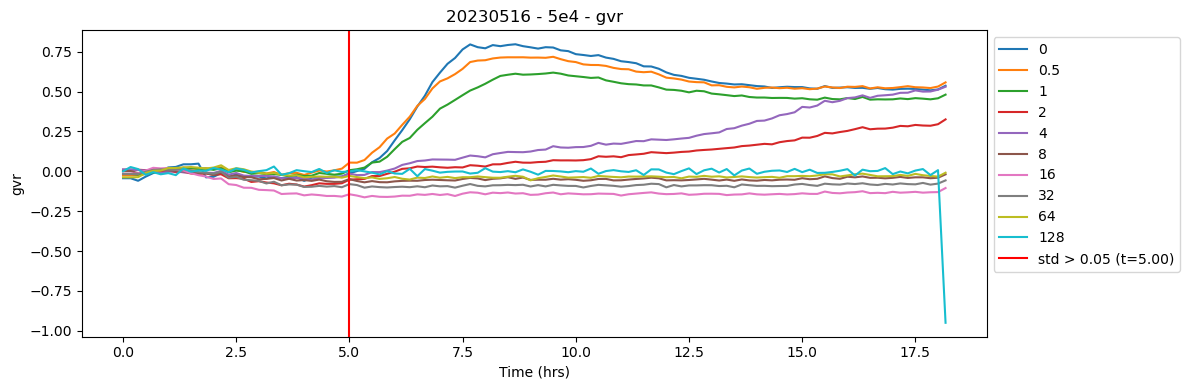


Antibiotico ampicillin |Experiment: 20230518  |  Concentration: 5e6
std inicial: 0.0046
std final: 0.9667


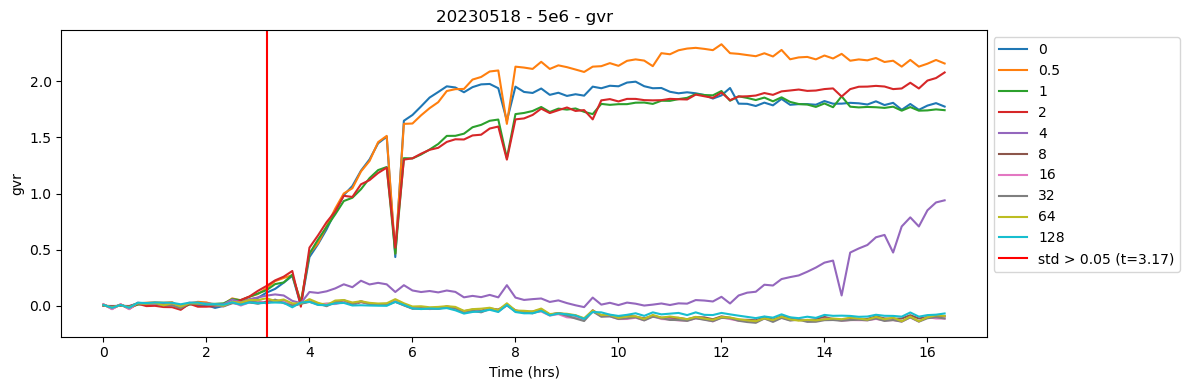


Antibiotico ampicillin |Experiment: 20230518  |  Concentration: 5e5
std inicial: 0.0035
std final: 0.6281


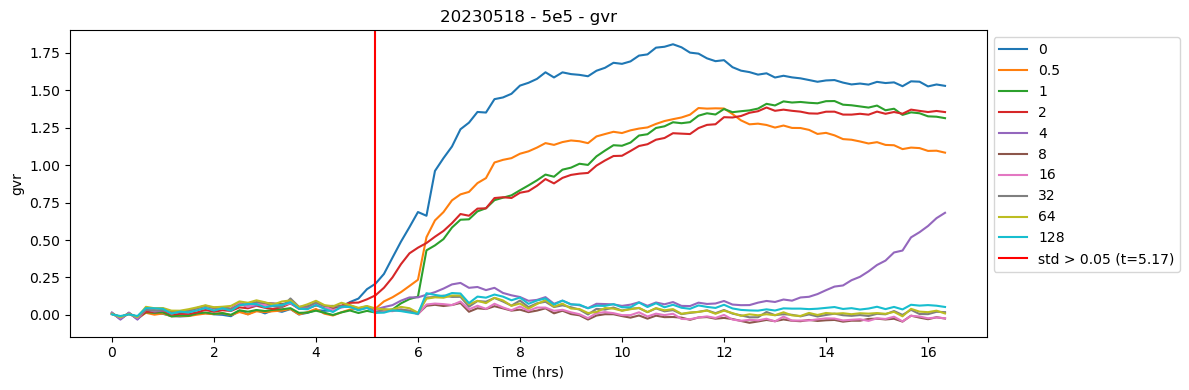


Antibiotico ampicillin |Experiment: 20230518  |  Concentration: 5e4
std inicial: 0.0060
std final: 1.2022


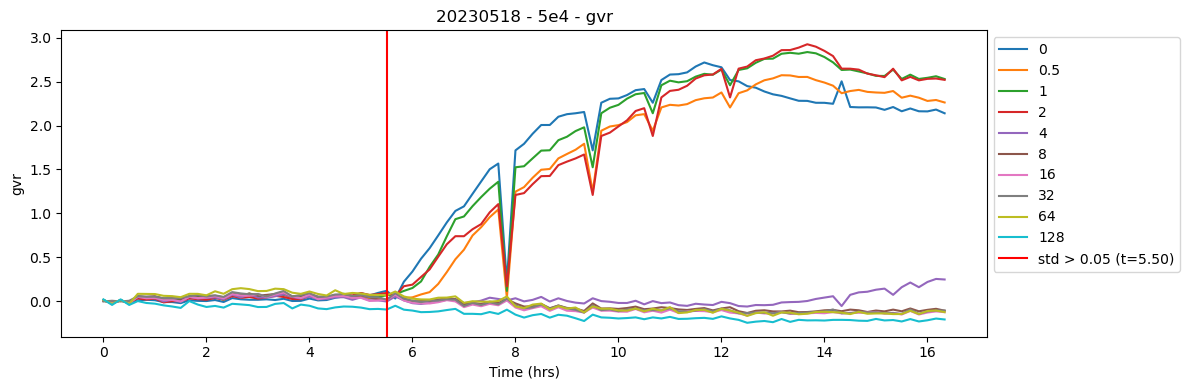


Antibiotico ciprofloxacin |Experiment: 20250717  |  Concentration: 5e5
std inicial: 0.0289
std final: 0.5996


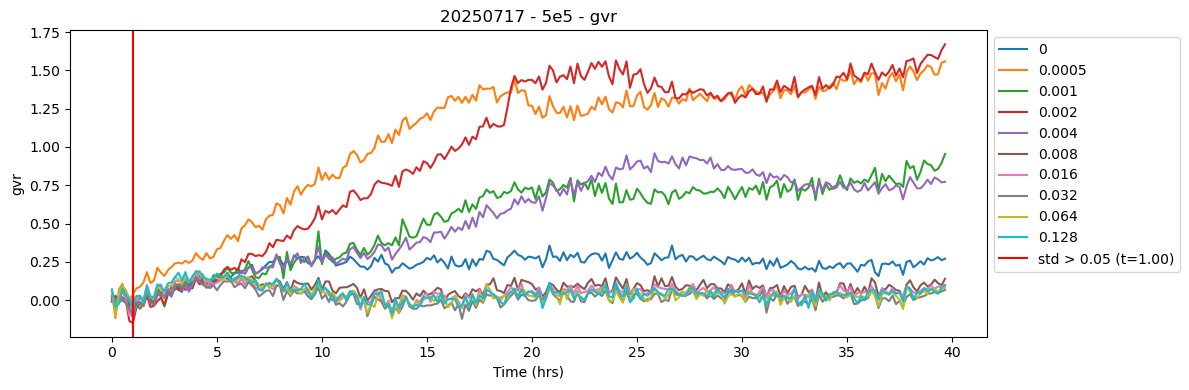


Antibiotico ciprofloxacin |Experiment: 20250719  |  Concentration: 5e5
std inicial: 0.0193
std final: 0.8553


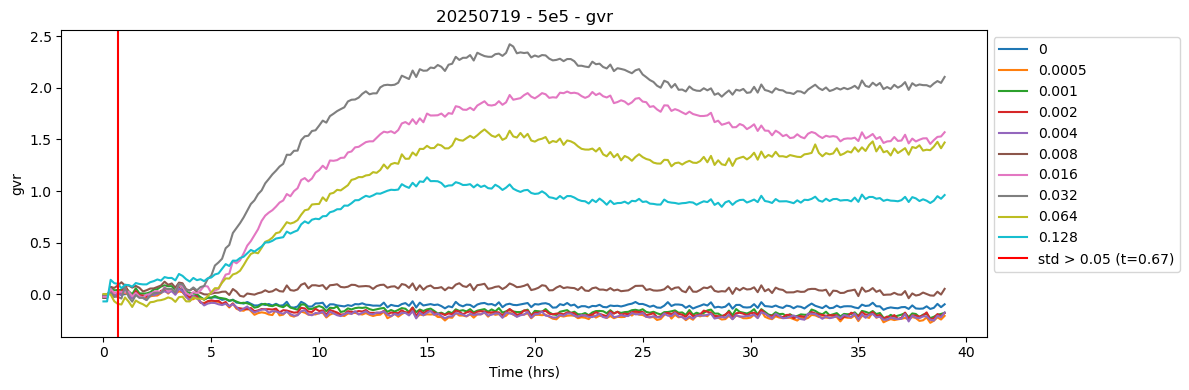


Antibiotico ciprofloxacin |Experiment: 20250728  |  Concentration: 5e5
std inicial: 0.0231
std final: 1.0253


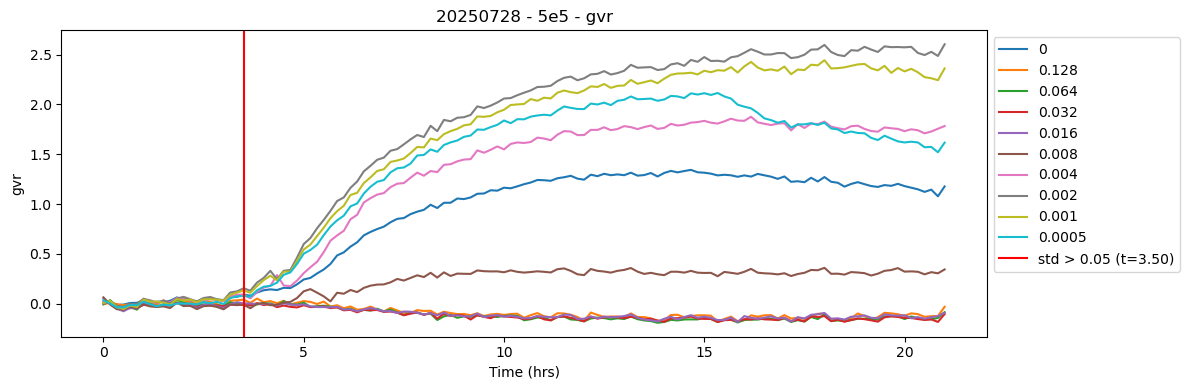


Antibiotico gentamicin |Experiment: 20250717  |  Concentration: 5e5
std inicial: 0.0219
std final: 0.5800


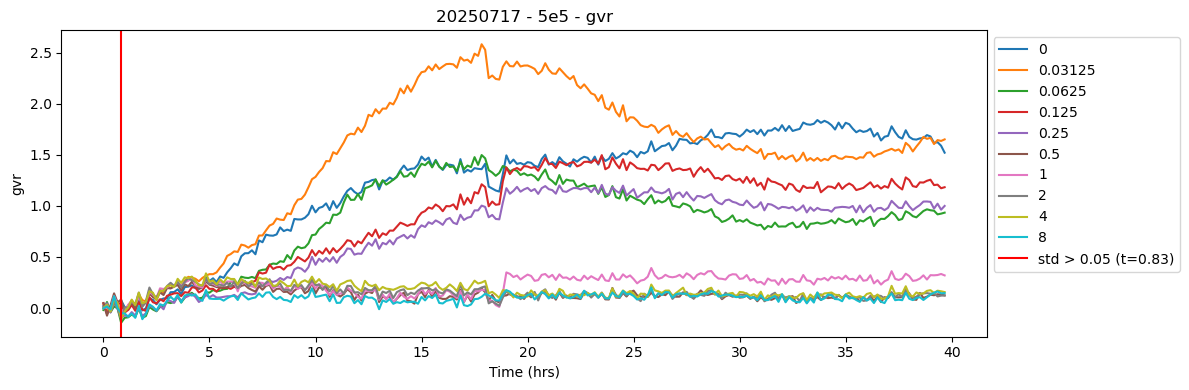


Antibiotico gentamicin |Experiment: 20250719  |  Concentration: 5e5
std inicial: 0.0052
std final: 0.0000


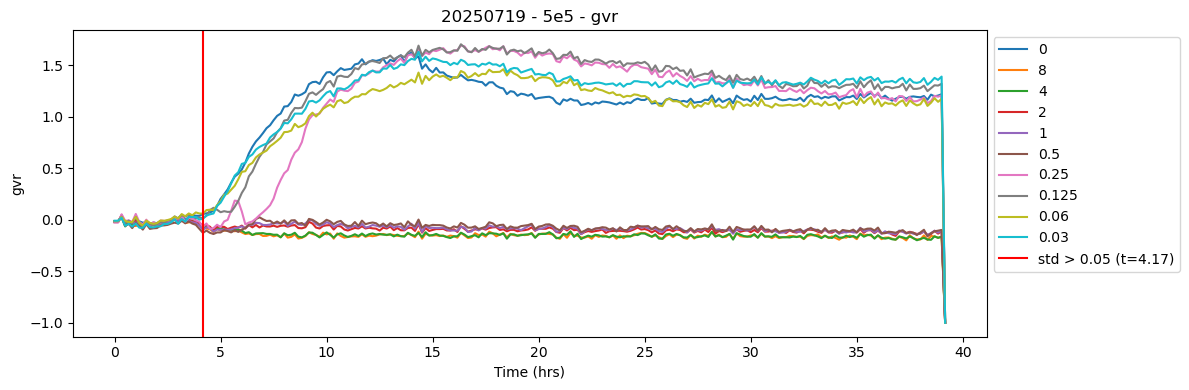


Antibiotico gentamicin |Experiment: 20250728  |  Concentration: 5e5
std inicial: 0.0163
std final: 1.0782


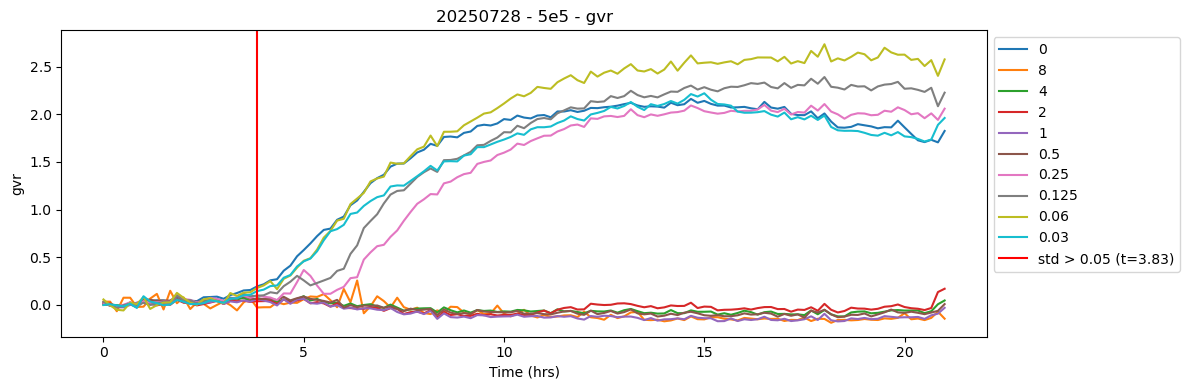


Antibiotico tetracycline |Experiment: 20240118  |  Concentration: 5e6
std inicial: 0.0821
std final: 0.4658


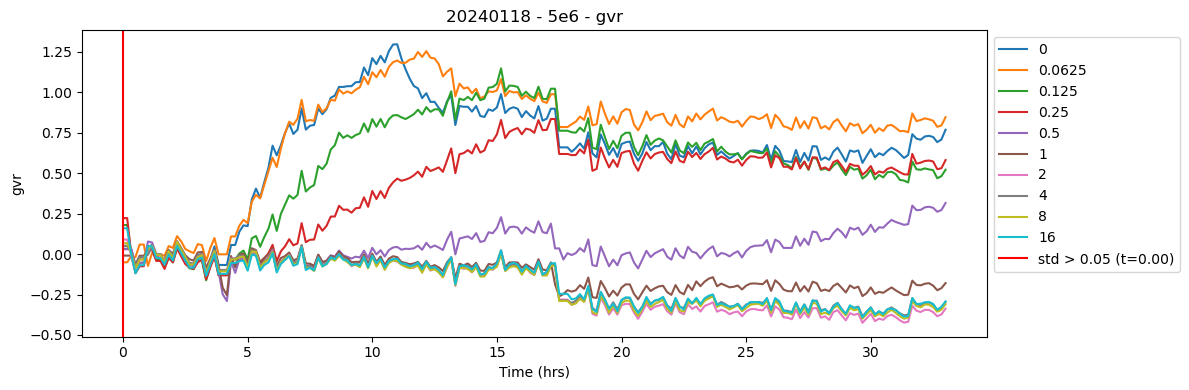


Antibiotico tetracycline |Experiment: 20240118  |  Concentration: 5e4
std inicial: 0.0031
std final: 0.5770


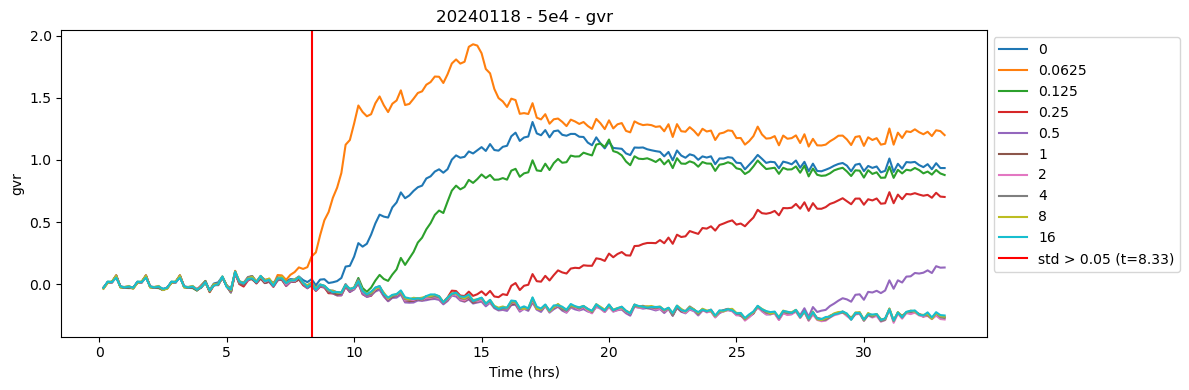


Antibiotico tetracycline |Experiment: 20240118  |  Concentration: 5e5
std inicial: 0.0581
std final: 0.5476


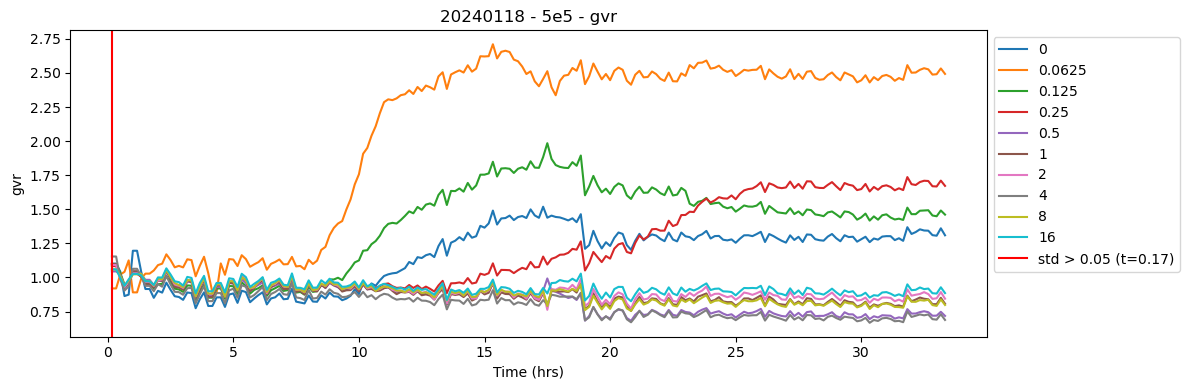


Antibiotico tetracycline |Experiment: 20240126  |  Concentration: 5e6
std inicial: 0.0223
std final: 1.0151


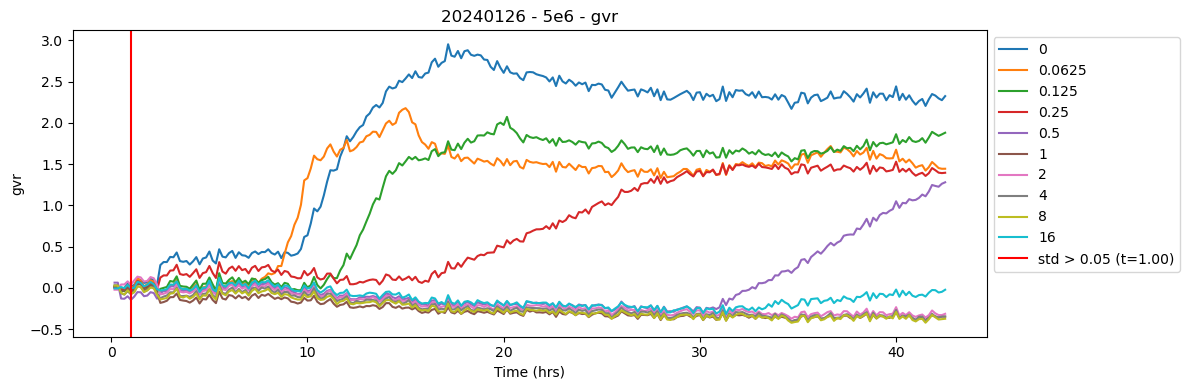


Antibiotico tetracycline |Experiment: 20240126  |  Concentration: 5e5
std inicial: 0.0223
std final: 1.0151


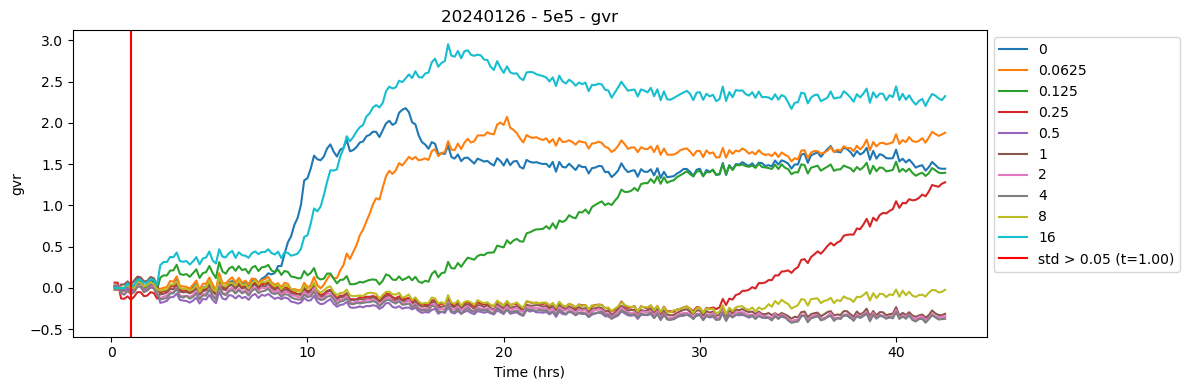


Antibiotico tetracycline |Experiment: 20240126  |  Concentration: 5e4
std inicial: 0.0195
std final: 0.7920


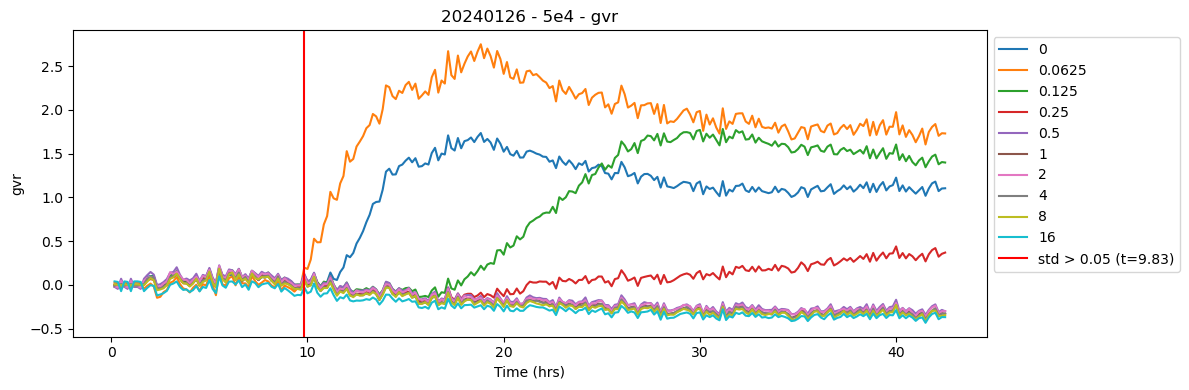


Antibiotico tetracycline |Experiment: 20240203  |  Concentration: 5e6
std inicial: 0.0513
std final: 0.4368


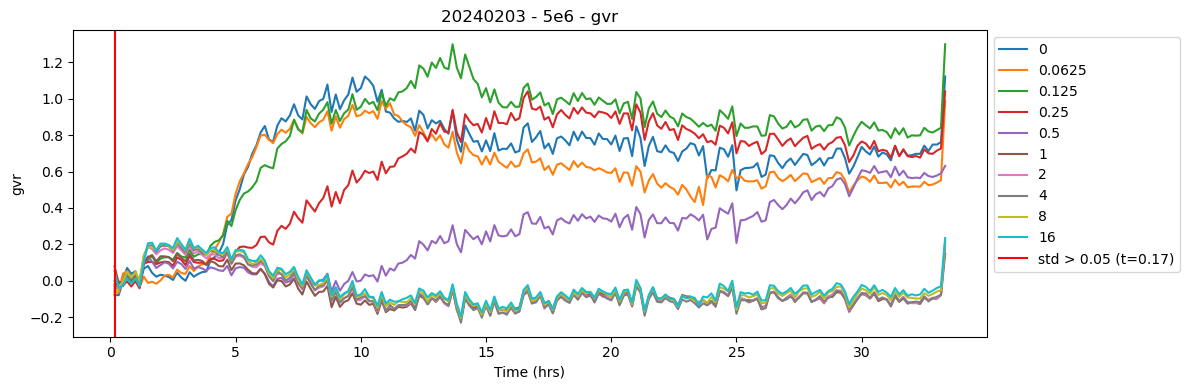


Antibiotico tetracycline |Experiment: 20240203  |  Concentration: 5e5
std inicial: 0.0443
std final: 0.5494


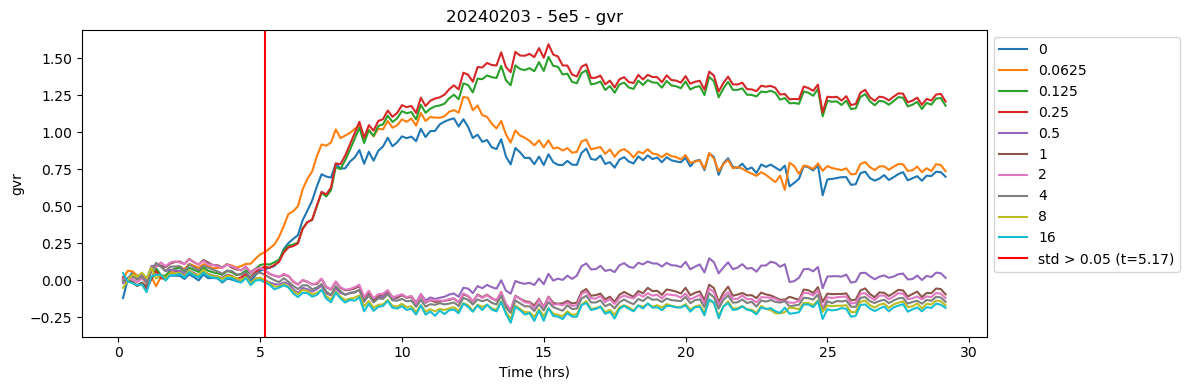


Antibiotico tetracycline |Experiment: 20240203  |  Concentration: 5e4
std inicial: 4.5038
std final: 0.5556


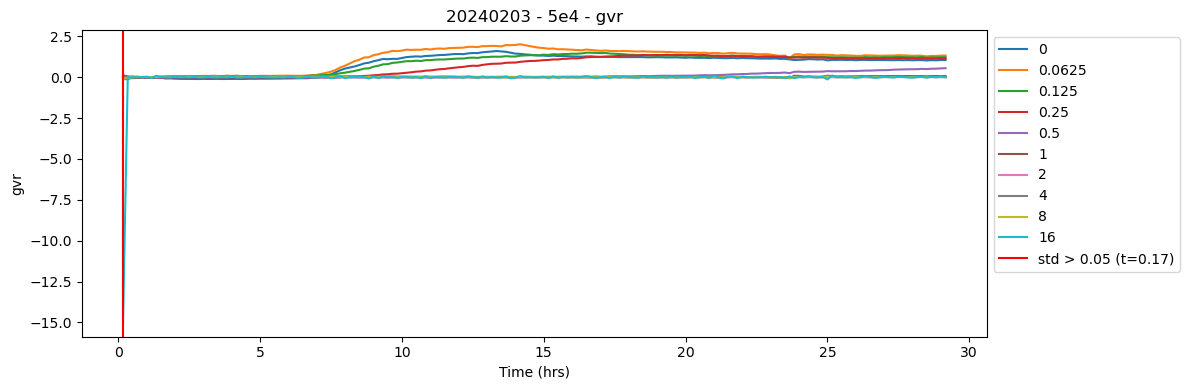


Antibiotico trimethoprim |Experiment: 20250717  |  Concentration: 5e5
std inicial: 0.0294
std final: 1.1434


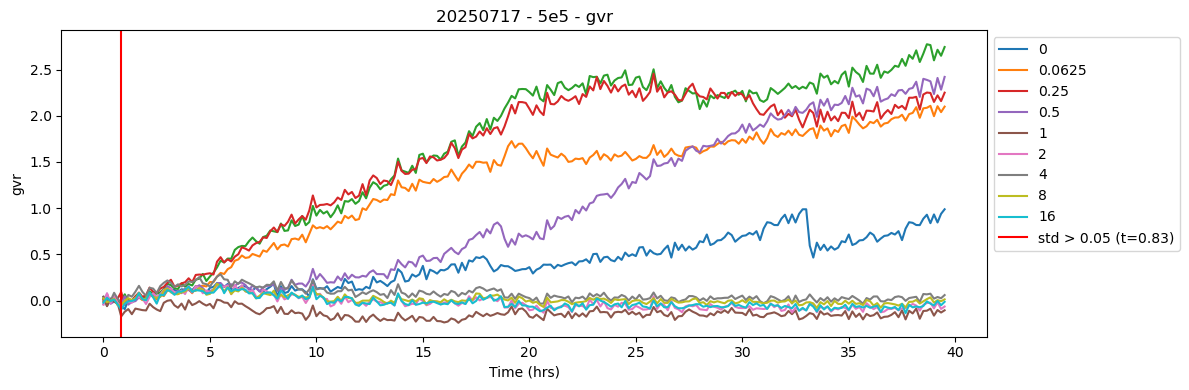


Antibiotico trimethoprim |Experiment: 20250719  |  Concentration: 5e5
std inicial: 0.0181
std final: 0.9370


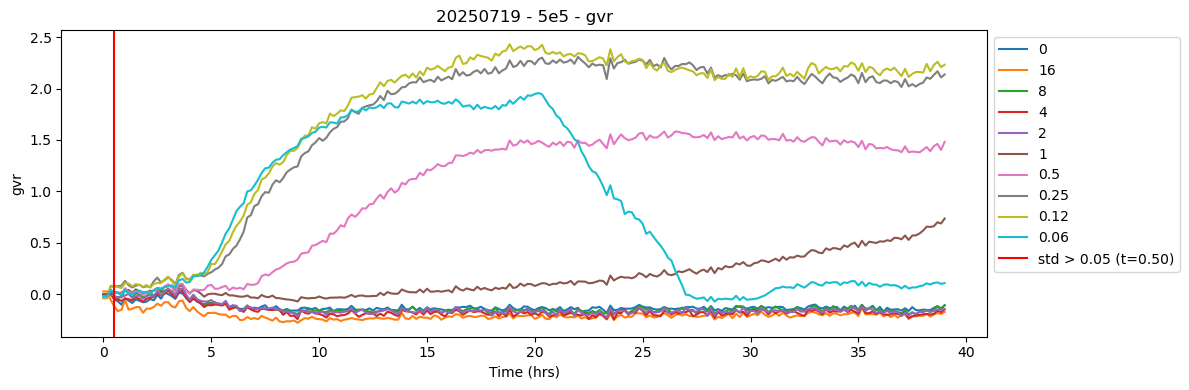


Antibiotico trimethoprim |Experiment: 20250728  |  Concentration: 5e5
std inicial: 0.0231
std final: 1.3353


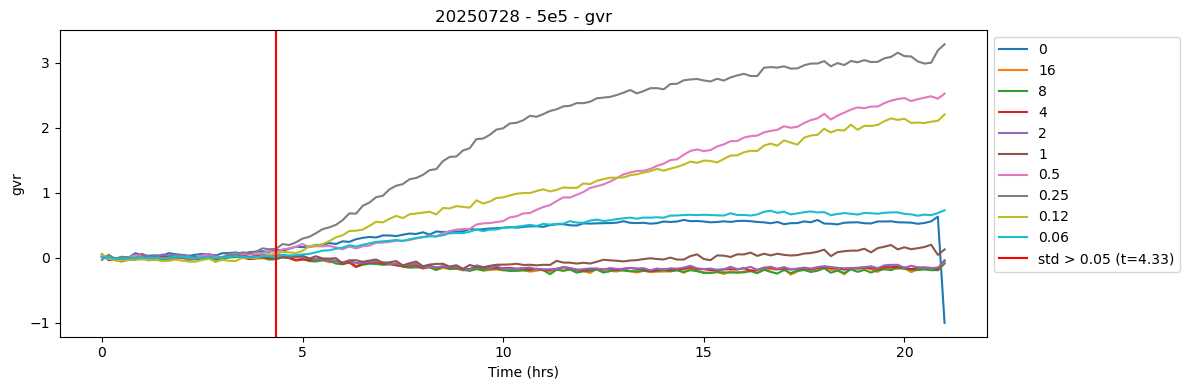

In [13]:
for antibiotico in ecoli_data:
    for date in ecoli_data[antibiotico]:
        for concentration in ecoli_data[antibiotico][date]:
            df = ecoli_data[antibiotico][date][concentration]["gvr"]

            print(f"Antibiotico {antibiotico} |Experiment: {date}  |  Concentration: {concentration}")
            time_threshold = get_std(df, "std")
            get_fig_std(date, concentration, df, "gvr", time_threshold)
            print()

## 6. S. AUREUS

### 6.1 Dataset Preparation

In [14]:
saureus_data = {}
for ficheiro in path_saureus:
    antibiotico = ficheiro[0]
    path = ficheiro[1]
    dados = get_dataset(path)
    dados = clean_Nas(dados)
    saureus_data.update({antibiotico : dados})

Sheet ignorada (sem brutos/gvr completo): 20251028_5e4


In [15]:
for antibiotico in saureus_data:
    for date in saureus_data[antibiotico]:
        for concentration in saureus_data[antibiotico][date]:
            for sample_type in saureus_data[antibiotico][date][concentration]:
                None

In [16]:
concs = set()
for antibiotico in saureus_data:
    for date in saureus_data[antibiotico]:
        for concentration in saureus_data[antibiotico][date]:
            for sample_type in saureus_data[antibiotico][date][concentration]:
                df = (saureus_data[antibiotico][date][concentration][sample_type])
                df.columns = [clean_conc(c) for c in df.columns]
                concs.update([c for c in df.columns if c != "Time(hrs)"])


### 6.2 Missing Value Assessment

In [17]:
na_found = False

for antibiotico in saureus_data:
    for date in saureus_data[antibiotico]:
        for concentration in saureus_data[antibiotico][date]:
            for sample_type in saureus_data[antibiotico][date][concentration]:
                df = (saureus_data[antibiotico][date][concentration][sample_type])
                if df.isna().any().any():
                    print(f"  NAs found in:{antibiotico} {date} - {concentration} - {sample_type}")
                    na_found = True

if not na_found:
    print("No missing values found in the dataset.")

No missing values found in the dataset.


### 6.3 S. aureus Data exploration

In [18]:
experiments  = list(saureus_data.keys())
bac_conc     = list(saureus_data[experiments[0]].keys())
data_types   = list(saureus_data[experiments[0]][bac_conc[0]].keys())

print("Experiments :", experiments)
print("Concentrations :", bac_conc)
print("Data types :", data_types)

Experiments : ['ampicillin', 'ciprofloxacin', 'gentamicin', 'tetracycline', 'trimethoprim', 'sulfamethoxazole']
Concentrations : ['20240128', '20240113', '20249999']
Data types : ['5e6']


In [19]:
duration = {}
for antibiotico in saureus_data:
    duration[antibiotico] = {}
    for date in saureus_data[antibiotico]:
        duration[antibiotico][date] = {}
        for concentration in saureus_data[antibiotico][date]:
            df = saureus_data[antibiotico][date][concentration]["gvr"]
            last_timepoint = round(df.iloc[-1, 0], 2)
            duration[antibiotico][date][concentration] = last_timepoint

print("Duration per condition (hours):")
print(duration)

Duration per condition (hours):
{'ampicillin': {'20240128': {'5e6': 33.17}, '20240113': {'5e6': 42.0, '5e5': 33.17, '5e4': 33.67}, '20249999': {'5ee': 59.83}}, 'ciprofloxacin': {'20250719': {'5e5': 41.17}, '20250721': {'5e5': 39.0}, '20250726': {'5e5': 41.0}, '20250820': {'5e4': 22.83, '5e6': 22.83}}, 'gentamicin': {'20250719': {'5e5': 41.17}, '20250721': {'5e5': 39.0}, '20250726': {'5e5': 41.0}, '20250822': {'5e6': 23.83, '5e4': 23.83}}, 'tetracycline': {'20251028': {'5e6': 19.17, '5e5': 29.17}, '20231203': {'5e5': 29.17}, '20231129': {'5e5': 29.17}, '20250810': {'5e6': 40.0, '5e5': 39.83, '5e4': 39.83}}, 'trimethoprim': {'20250719': {'5e5': 41.17}, '20250721': {'5e5': 39.0}, '20250726': {'5e5': 41.0}, '20250822': {'5e6': 25.0, '5e4': 25.0}}, 'sulfamethoxazole': {'20250719': {'5e5': 41.17}, '20250812': {'5e6': 17.0, '5e4': 17.0}, '20250721': {'5e5': 39.0}, '20250726': {'5e5': 41.0}}}


### 6.4 Display Dataset

In [20]:
for antibiotico in ecoli_data:
    for date in ecoli_data[antibiotico]:
        for concentration in ecoli_data[antibiotico][date]:
            df = ecoli_data[antibiotico][date][concentration]["gvr"]
            #display(df) 

### 6.5 Standard deviation analysis (GVR)

Antibiotico ampicillin |Experiment: 20240128  |  Concentration: 5e6
std inicial: 0.0168
std final: 0.3451


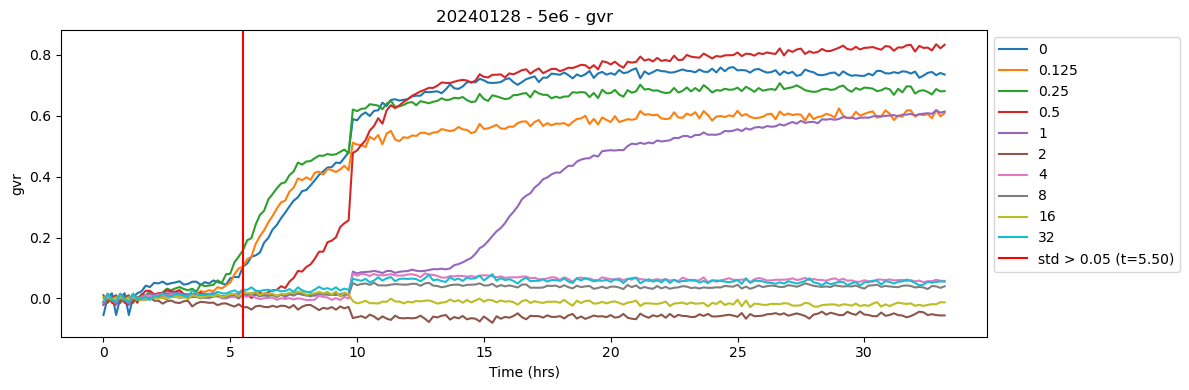


Antibiotico ampicillin |Experiment: 20240113  |  Concentration: 5e6
std inicial: 0.0000
std final: 0.2195


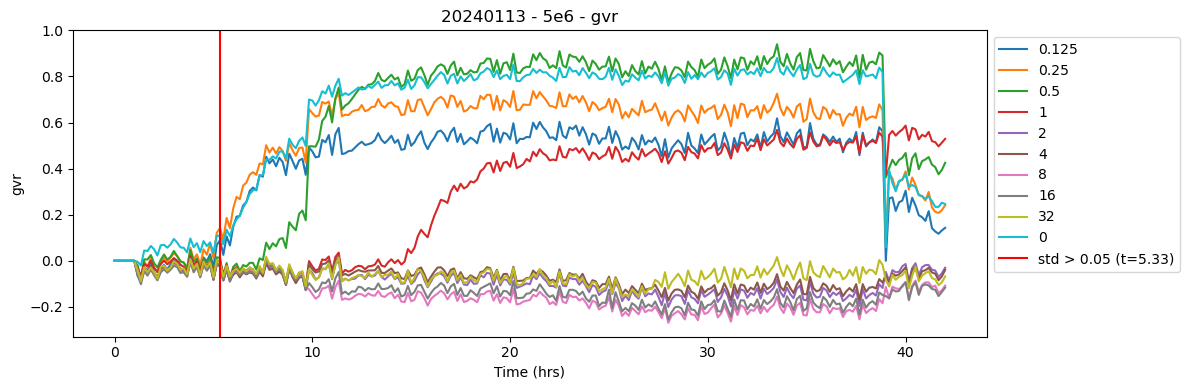


Antibiotico ampicillin |Experiment: 20240113  |  Concentration: 5e5
std inicial: 0.0880
std final: 0.3797


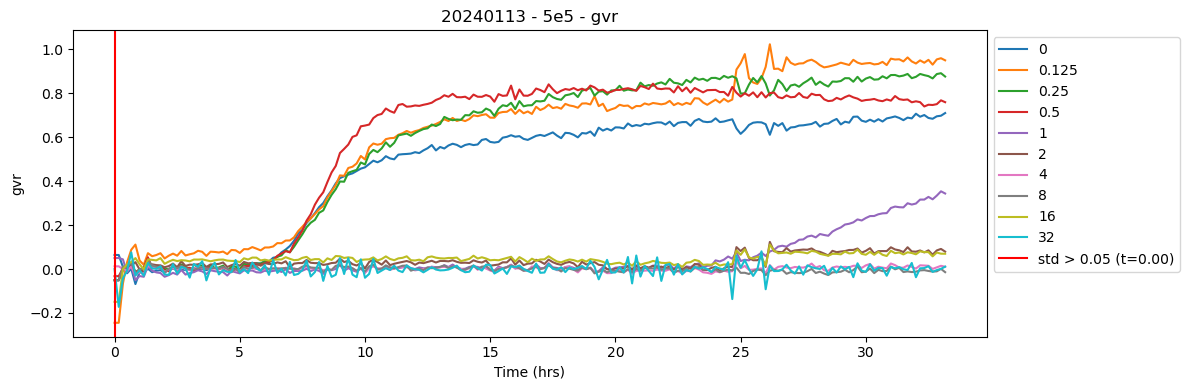


Antibiotico ampicillin |Experiment: 20240113  |  Concentration: 5e4
std inicial: 0.0464
std final: 0.5928


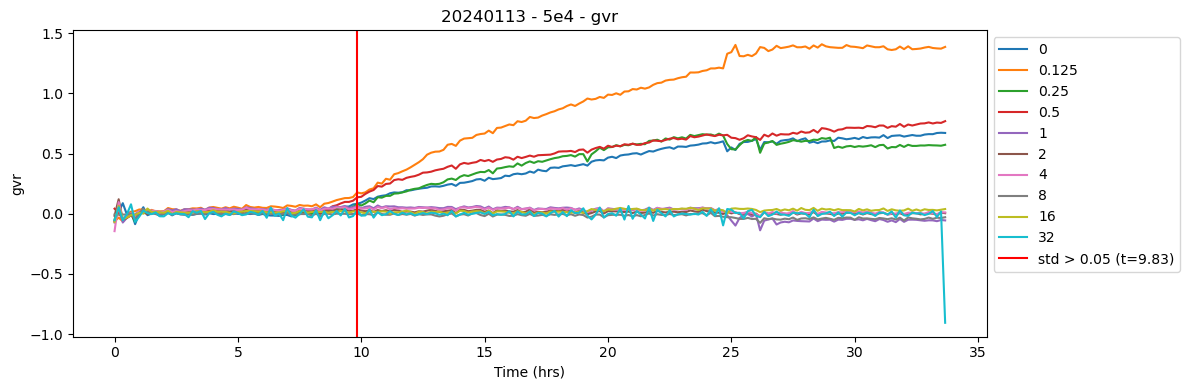


Antibiotico ampicillin |Experiment: 20249999  |  Concentration: 5ee
std inicial: 0.1474
std final: 0.6064


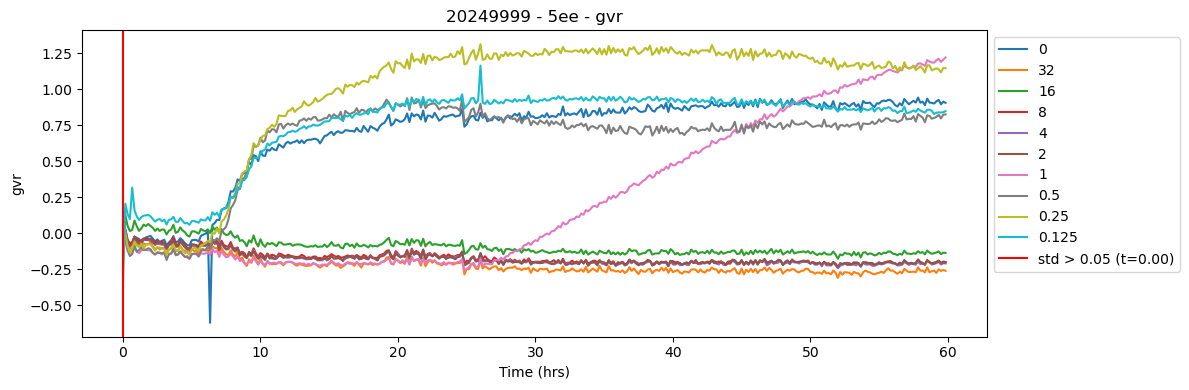


Antibiotico ciprofloxacin |Experiment: 20250719  |  Concentration: 5e5
std inicial: 0.0186
std final: 0.5929


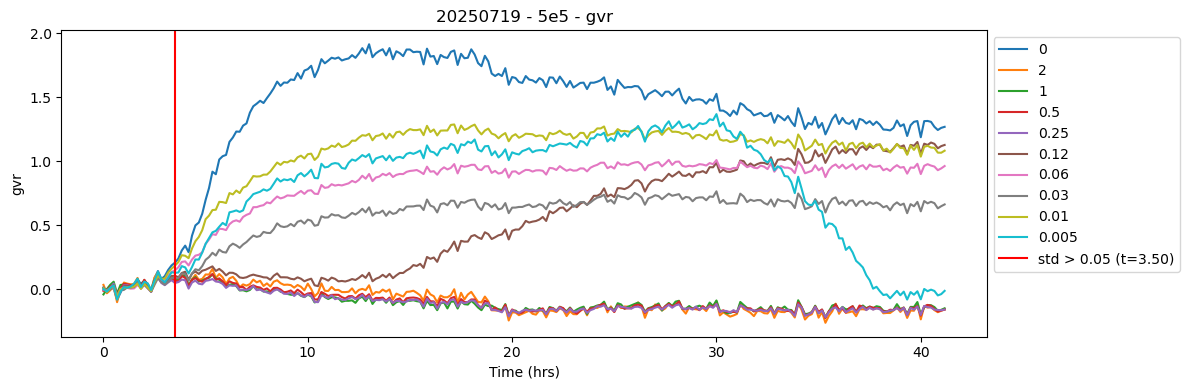


Antibiotico ciprofloxacin |Experiment: 20250721  |  Concentration: 5e5
std inicial: 0.0112
std final: 0.7595


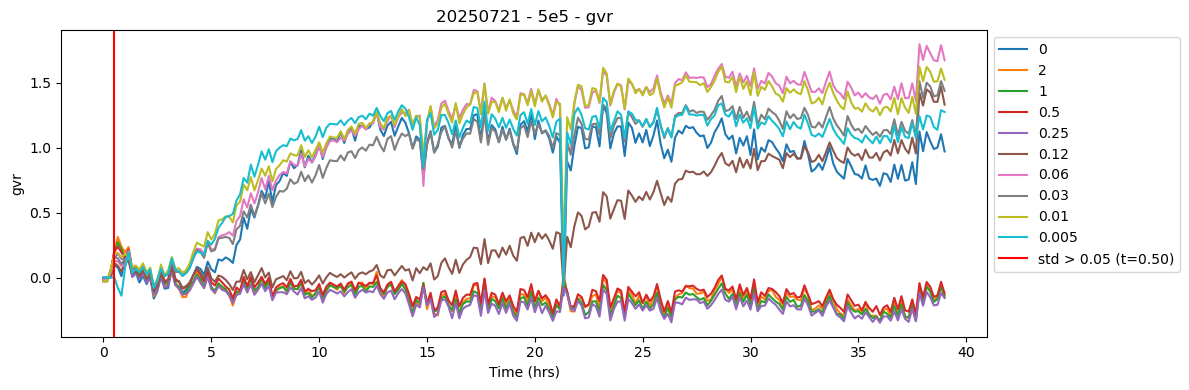


Antibiotico ciprofloxacin |Experiment: 20250726  |  Concentration: 5e5
std inicial: 0.0101
std final: 1.5837


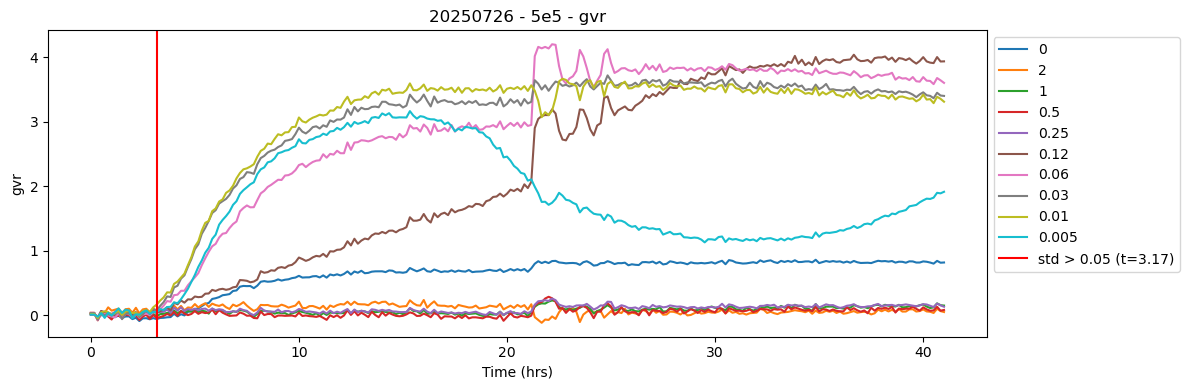


Antibiotico ciprofloxacin |Experiment: 20250820  |  Concentration: 5e4
std inicial: 0.0060
std final: 0.5679


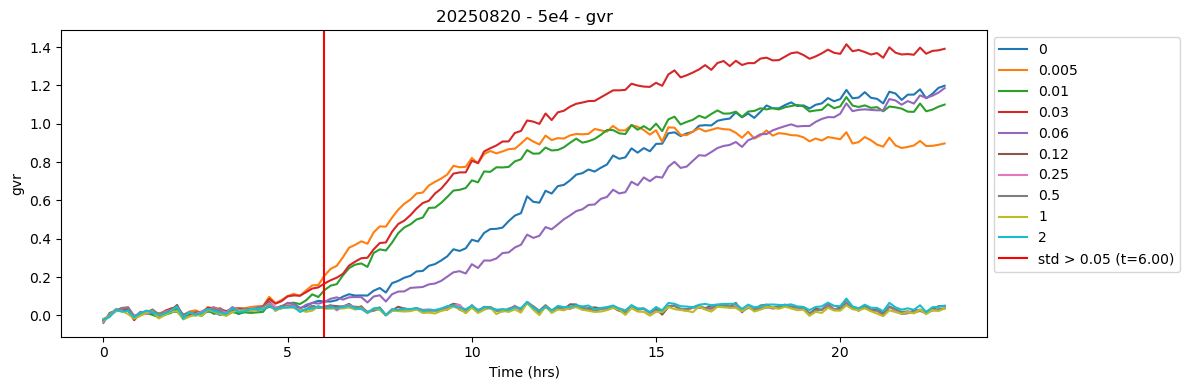


Antibiotico ciprofloxacin |Experiment: 20250820  |  Concentration: 5e6
std inicial: 0.0106
std final: 0.5418


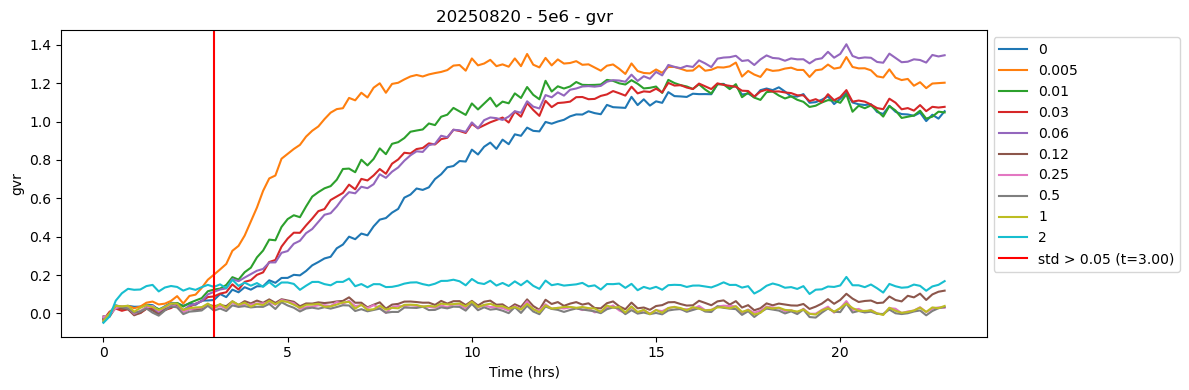


Antibiotico gentamicin |Experiment: 20250719  |  Concentration: 5e5
std inicial: 0.0251
std final: 11.6338


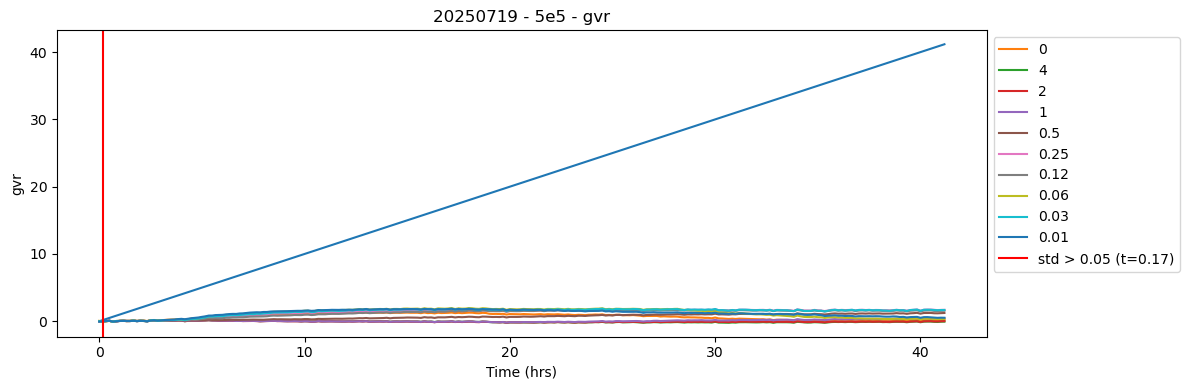


Antibiotico gentamicin |Experiment: 20250721  |  Concentration: 5e5
std inicial: 0.0090
std final: 0.6263


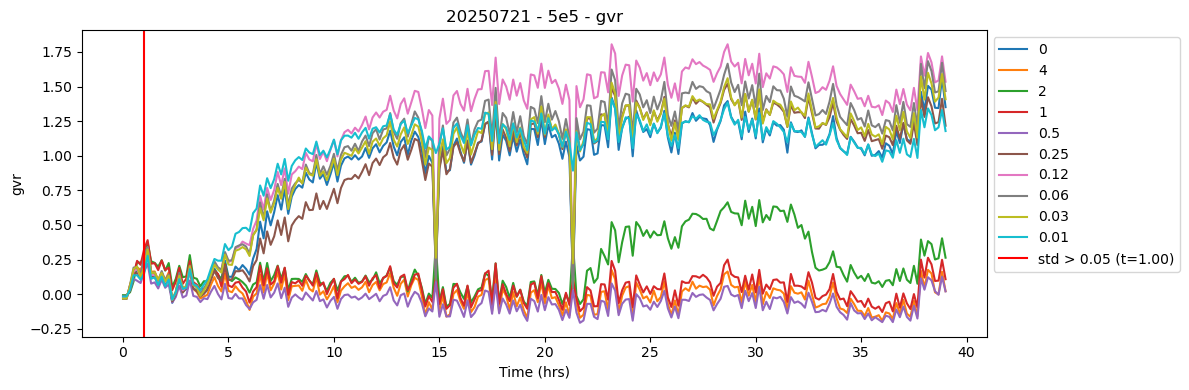


Antibiotico gentamicin |Experiment: 20250726  |  Concentration: 5e5
std inicial: 0.0129
std final: 1.5594


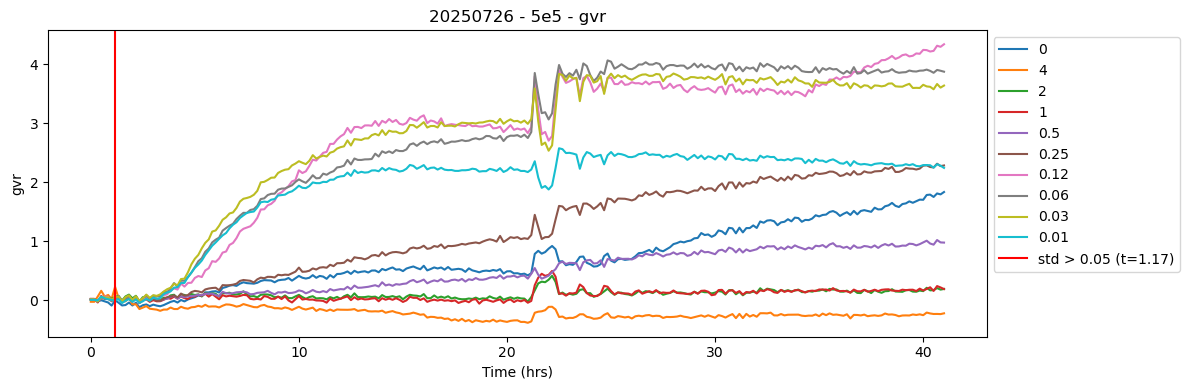


Antibiotico gentamicin |Experiment: 20250822  |  Concentration: 5e6
std inicial: 0.0037
std final: 0.3753


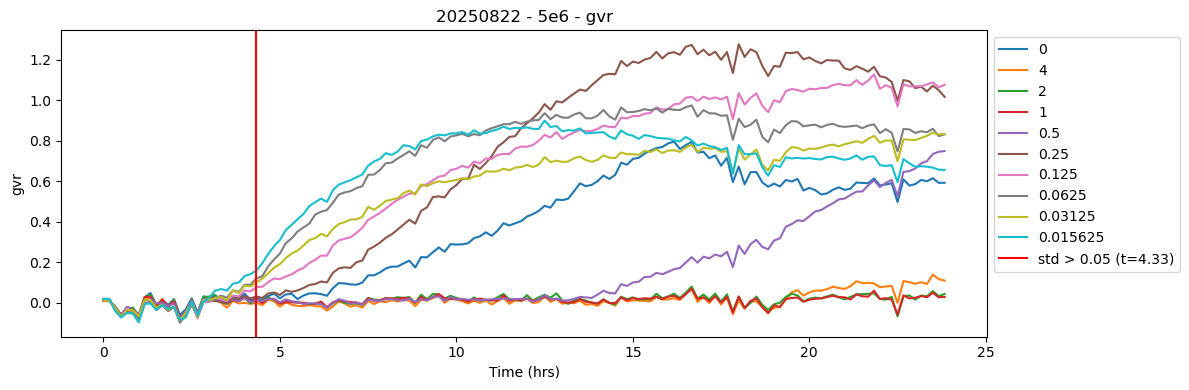


Antibiotico gentamicin |Experiment: 20250822  |  Concentration: 5e4
std inicial: 0.0029
std final: 0.4237


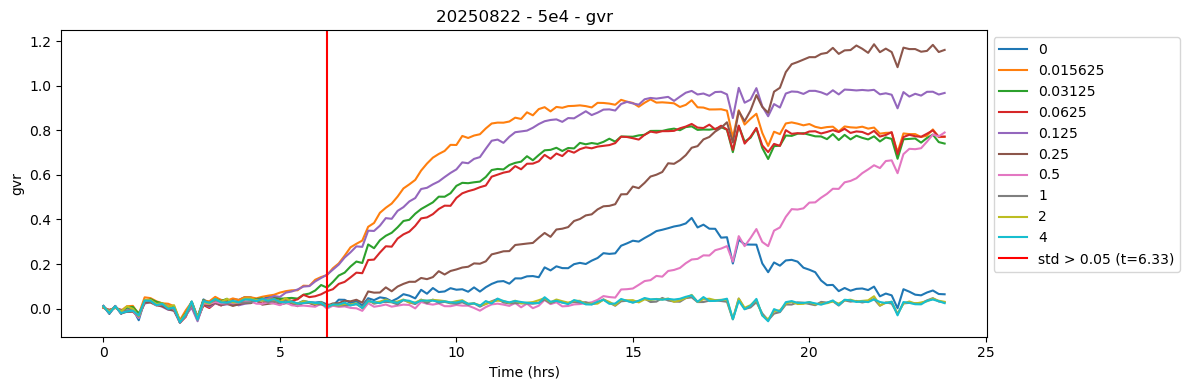


Antibiotico tetracycline |Experiment: 20251028  |  Concentration: 5e6
std inicial: 0.0381
std final: 0.3644


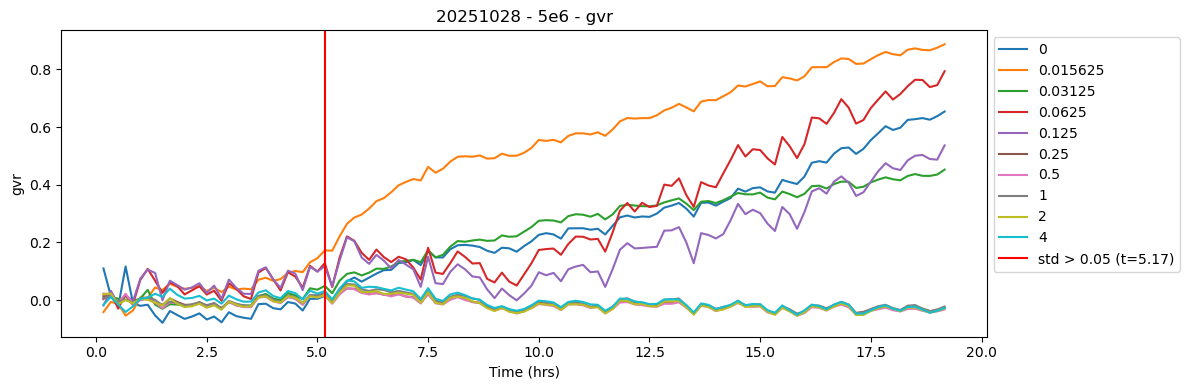


Antibiotico tetracycline |Experiment: 20251028  |  Concentration: 5e5
std inicial: 0.0399
std final: 0.3344


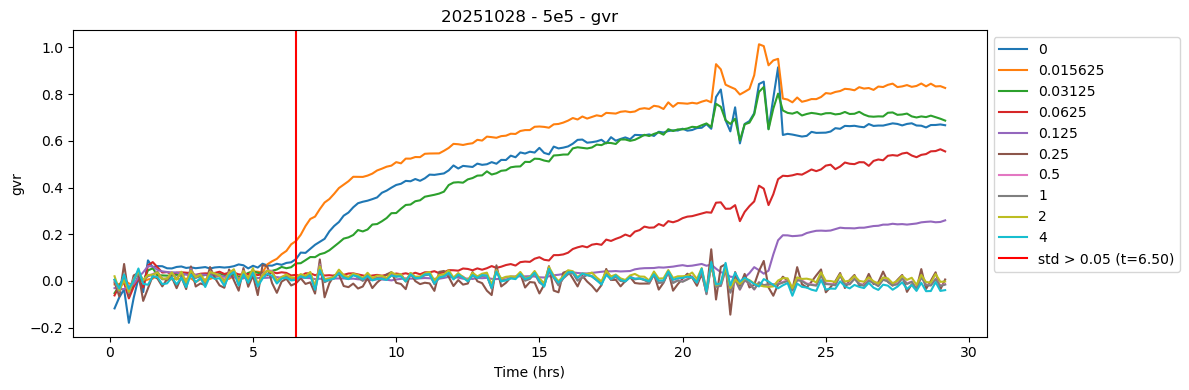


Antibiotico tetracycline |Experiment: 20231203  |  Concentration: 5e5
std inicial: 0.0241
std final: 0.3387


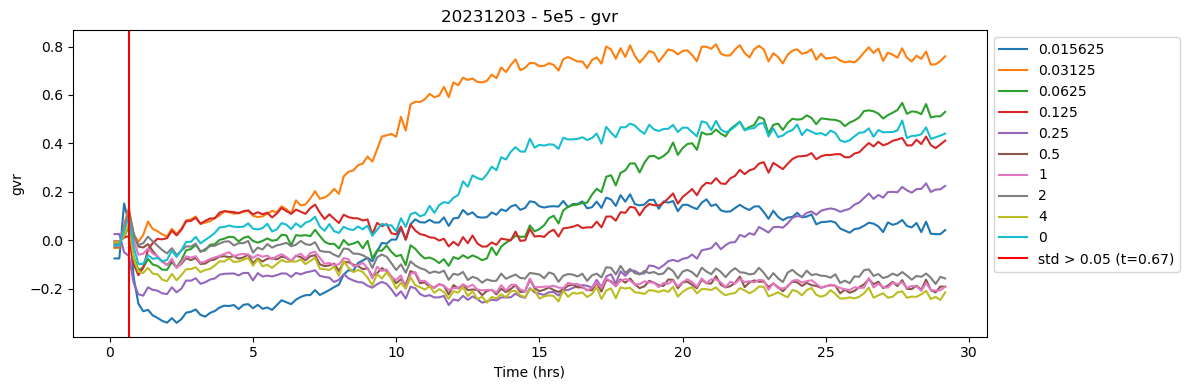


Antibiotico tetracycline |Experiment: 20231129  |  Concentration: 5e5
std inicial: 0.0023
std final: 0.5286


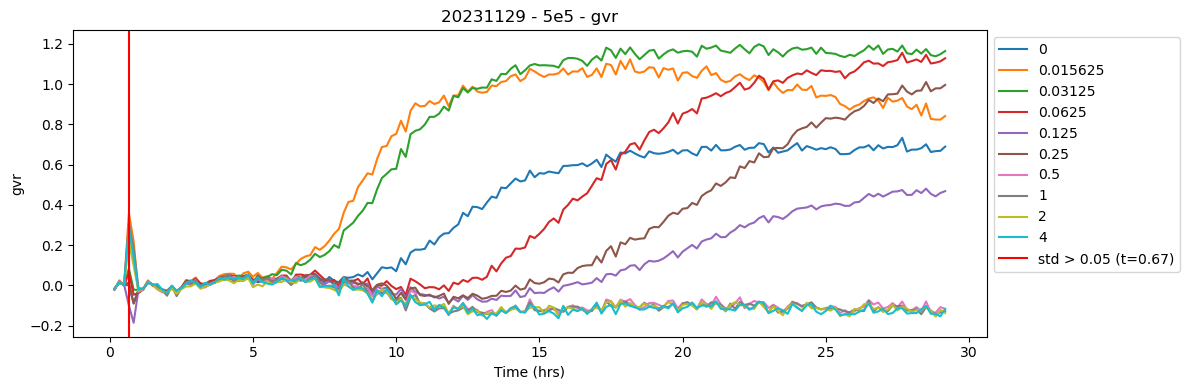


Antibiotico tetracycline |Experiment: 20250810  |  Concentration: 5e6
std inicial: 0.0121
std final: 0.1954


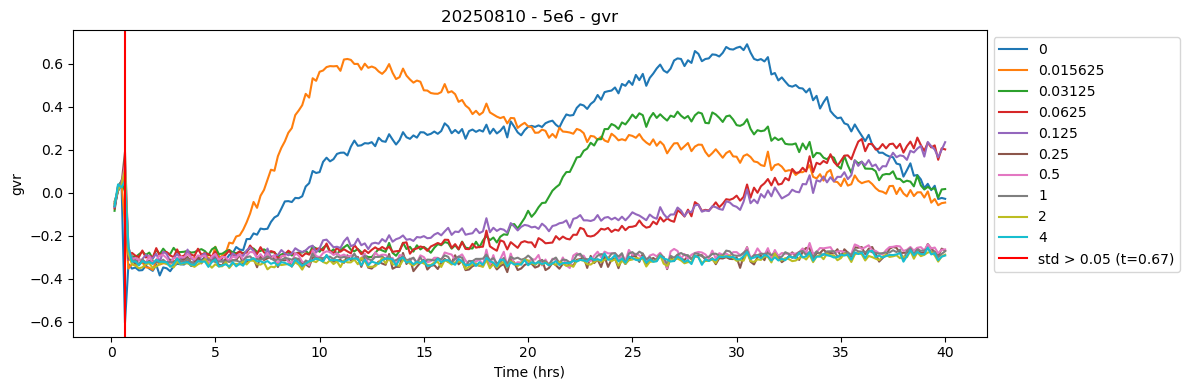


Antibiotico tetracycline |Experiment: 20250810  |  Concentration: 5e5
std inicial: 0.0087
std final: 0.3628


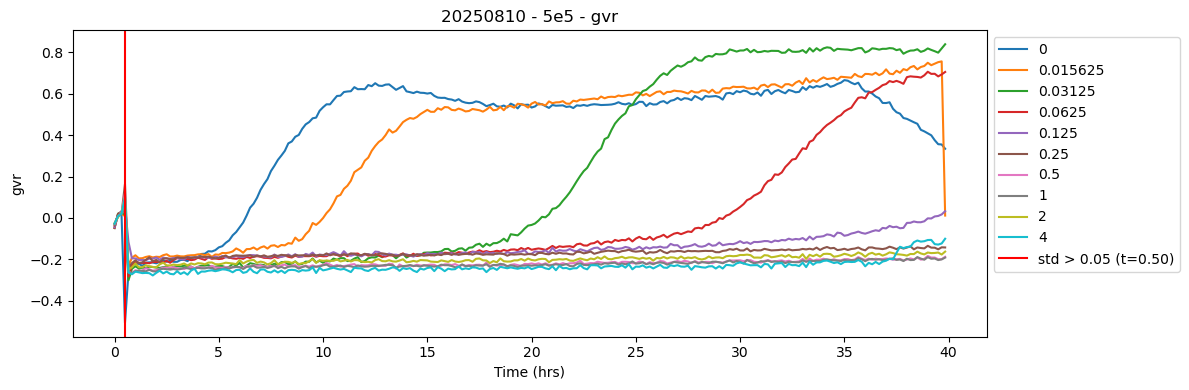


Antibiotico tetracycline |Experiment: 20250810  |  Concentration: 5e4
std inicial: 0.0437
std final: 0.9572


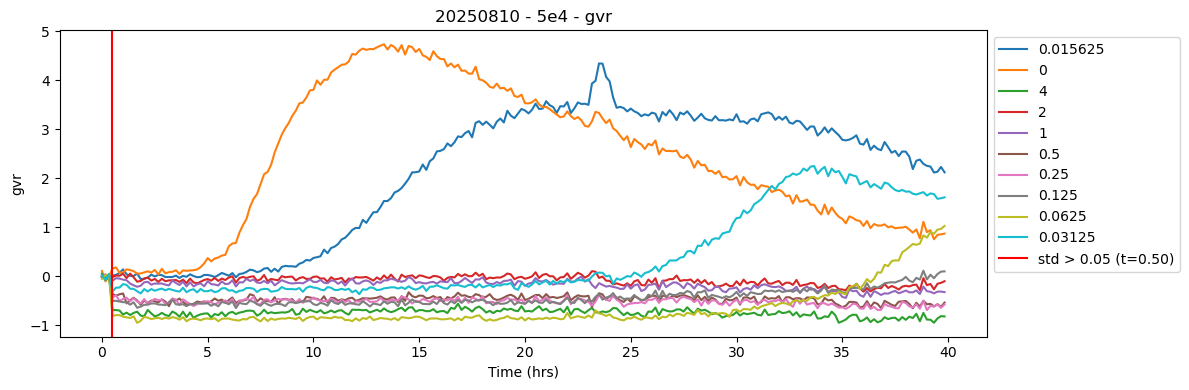


Antibiotico trimethoprim |Experiment: 20250719  |  Concentration: 5e5
std inicial: 0.0322
std final: 1.0994


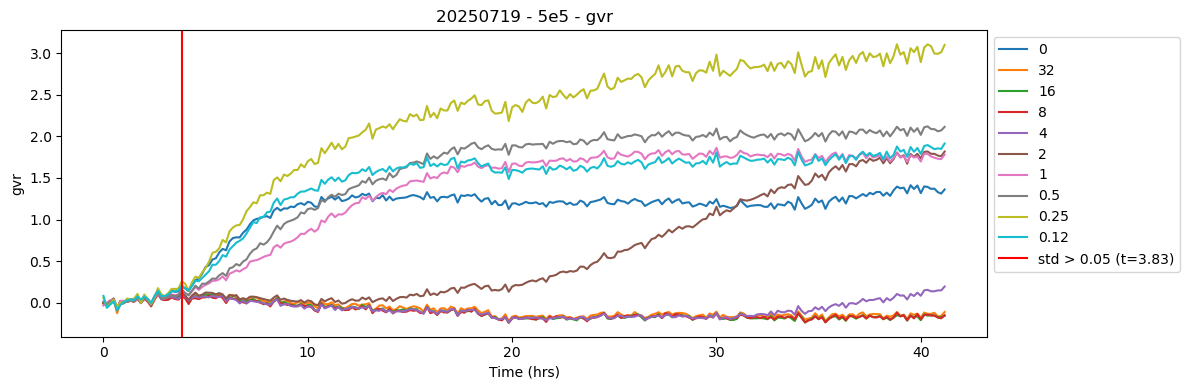


Antibiotico trimethoprim |Experiment: 20250721  |  Concentration: 5e5
std inicial: 0.0157
std final: 0.8194


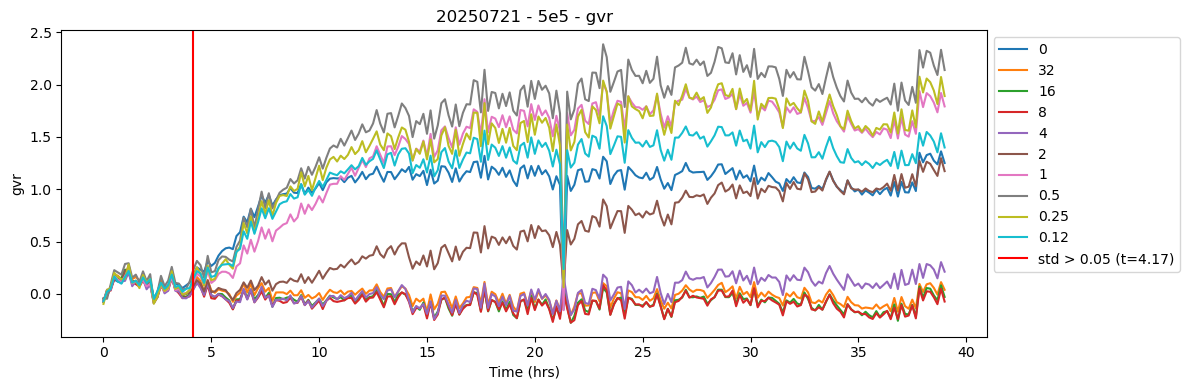


Antibiotico trimethoprim |Experiment: 20250726  |  Concentration: 5e5
std inicial: 0.0071
std final: 1.4914


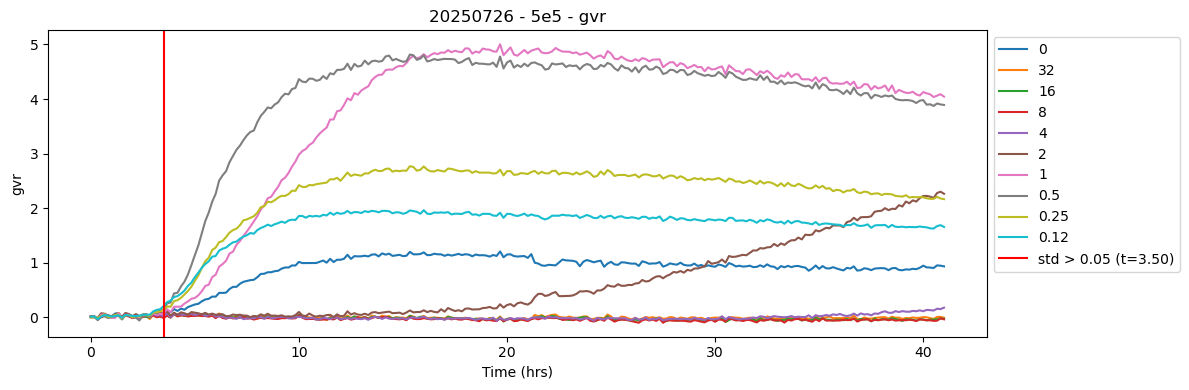


Antibiotico trimethoprim |Experiment: 20250822  |  Concentration: 5e6
std inicial: 0.0025
std final: 0.0258


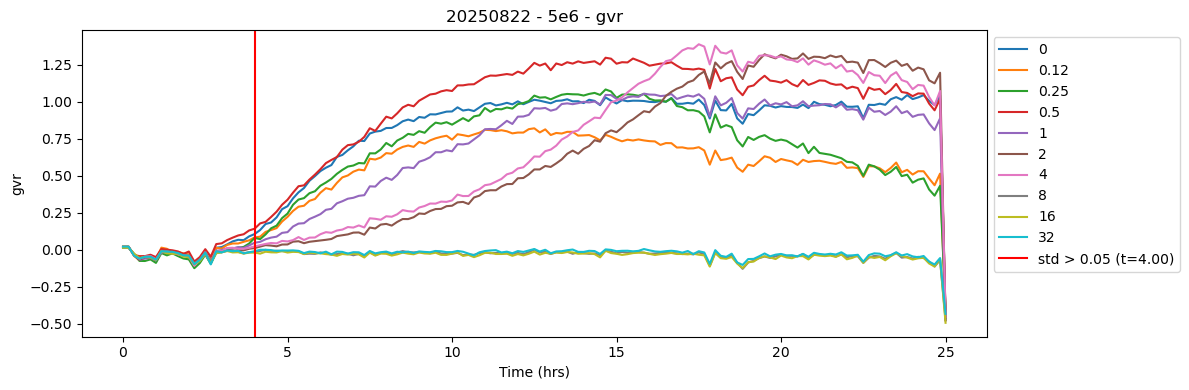


Antibiotico trimethoprim |Experiment: 20250822  |  Concentration: 5e4
std inicial: 0.0793
std final: 0.0354


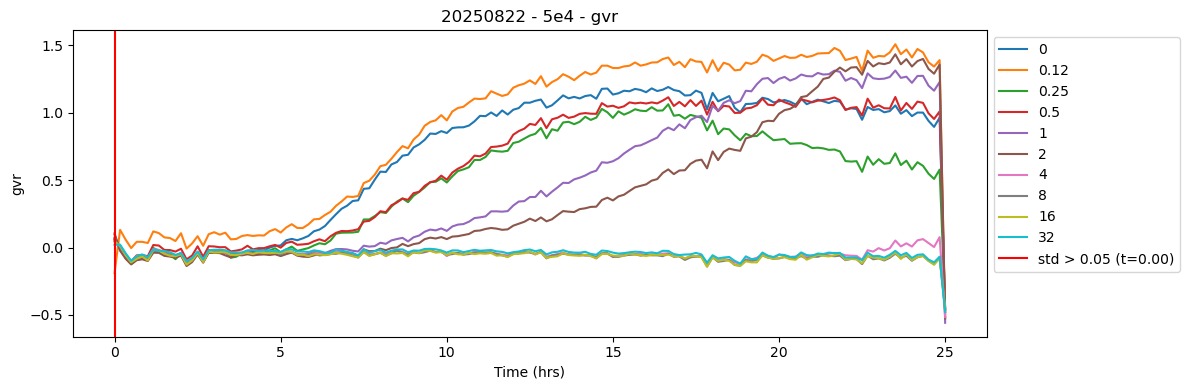


Antibiotico sulfamethoxazole |Experiment: 20250719  |  Concentration: 5e5
std inicial: 0.0179
std final: 0.5695


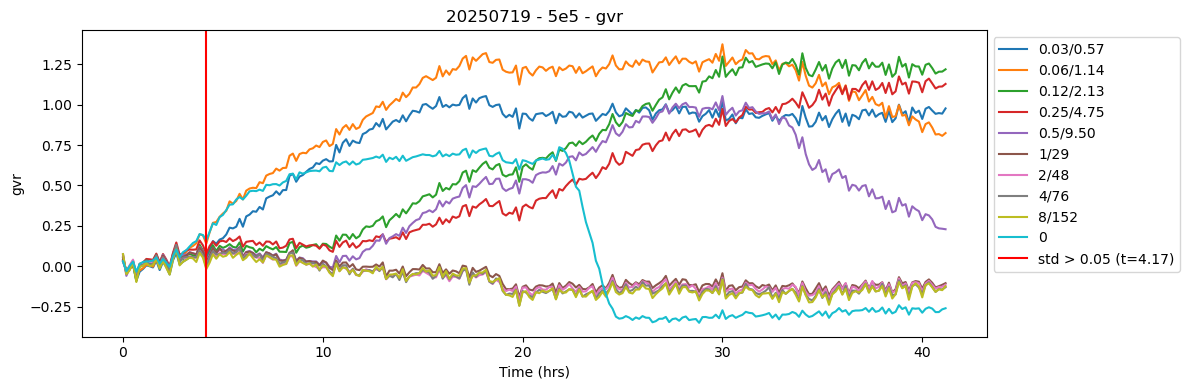


Antibiotico sulfamethoxazole |Experiment: 20250812  |  Concentration: 5e6
std inicial: 0.0054
std final: 0.5484


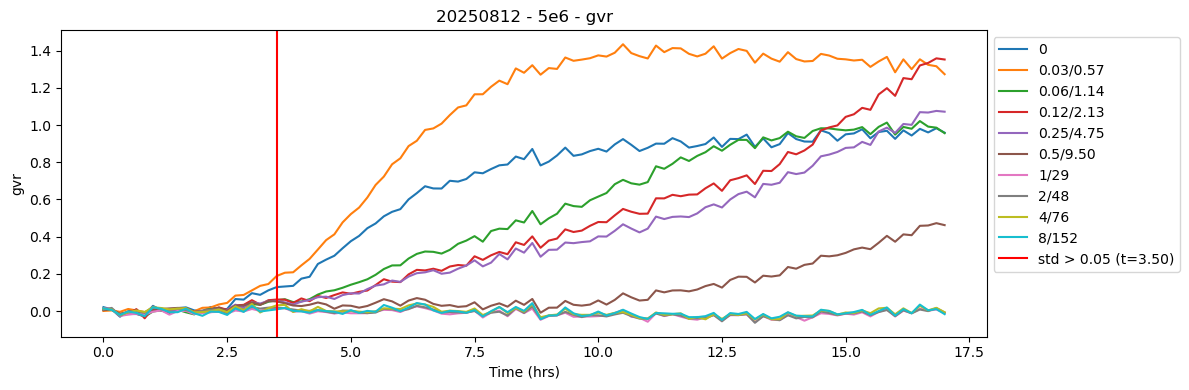


Antibiotico sulfamethoxazole |Experiment: 20250812  |  Concentration: 5e4
std inicial: 0.0084
std final: 0.4141


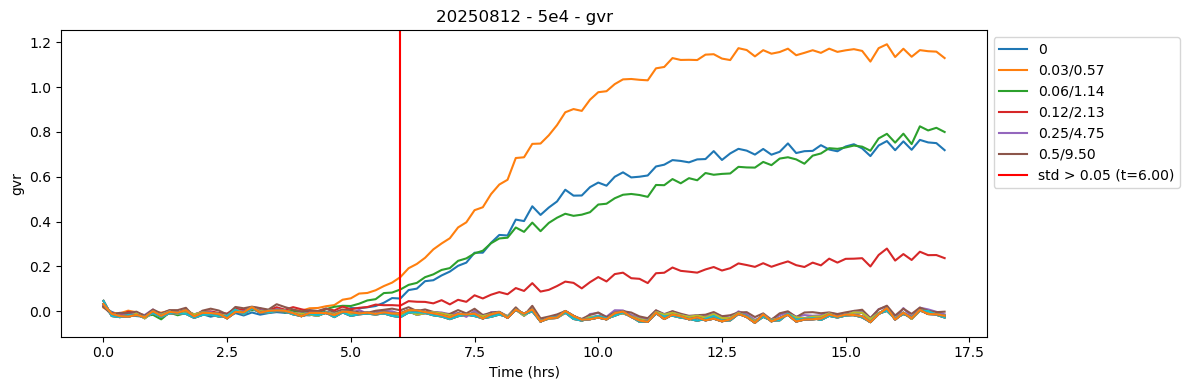


Antibiotico sulfamethoxazole |Experiment: 20250721  |  Concentration: 5e5
std inicial: 0.0101
std final: 0.6464


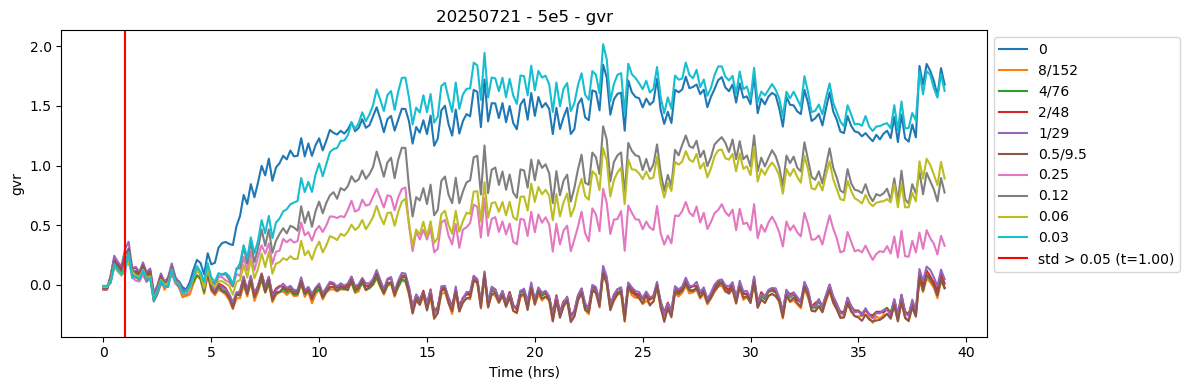


Antibiotico sulfamethoxazole |Experiment: 20250726  |  Concentration: 5e5
std inicial: 0.0036
std final: 1.2119


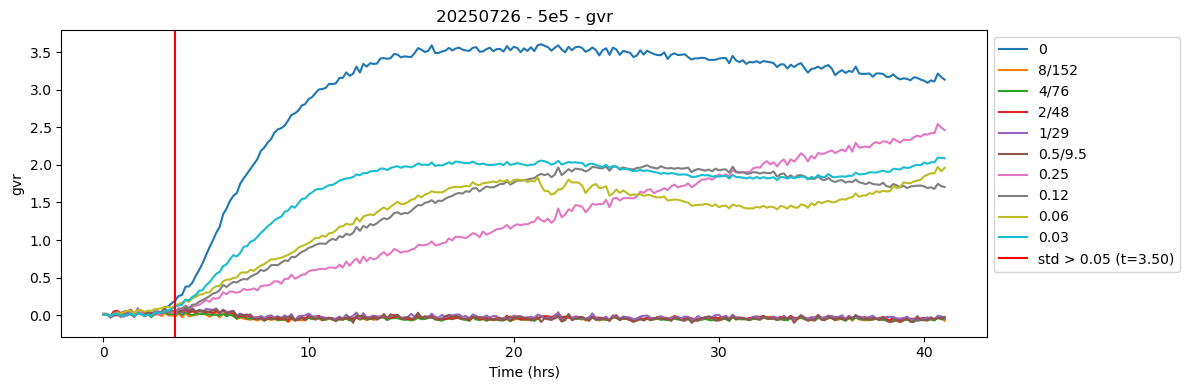

In [21]:
for antibiotico in saureus_data:
    for date in saureus_data[antibiotico]:
        for concentration in saureus_data[antibiotico][date]:
            df = saureus_data[antibiotico][date][concentration]["gvr"]

            print(f"Antibiotico {antibiotico} |Experiment: {date}  |  Concentration: {concentration}")
            time_threshold = get_std(df, "std")
            get_fig_std(date, concentration, df, "gvr", time_threshold)
            print()

## 7. Save Dataset

In [22]:
with open("ecoli_data.pkl", "wb") as f:
    pickle.dump(ecoli_data, f)

print("Dataset saved successfully.")

Dataset saved successfully.


In [23]:
with open("saureus_data.pkl", "wb") as f:
    pickle.dump(saureus_data, f)

print("Dataset saved successfully.")

Dataset saved successfully.
